In [234]:
#Part 1: Business Framing & Exploratory Analysis
#Task 1: Explore the Data as a KPI Story

import pandas as pd

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [235]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


## Task 1 — Findings

Overall churn rate: 26.54% (1,869 out of 7,043 customers).

Churn by contract: Month-to-month customers have the highest churn
rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

Churn by InternetService: Fiber optic customers have the highest churn rate at 41.89%, followed by DSL at 18.96%. Customers without internet service have the lowest churn rate at 7.40%.

Tenure vs churn: Customers who churned had an average tenure of 17.98 months, compared with 37.57 months for customers who did not churn. This indicates that shorter-tenure customers are associated with higher churn risk.

Tenure-churn correlation: The correlation between tenure and churn is -0.3522, indicating a moderate negative relationship. Customers with longer tenure tend to be less likely to churn, although correlation does not prove causation.

In [236]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [237]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [238]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [239]:
df["Churn_numeric"] = df["Churn"].map({"No": 0, "Yes": 1})

df["tenure"].corr(df["Churn_numeric"])

np.float64(-0.352228670113078)

#Tenure-churn correlation: The correlation between tenure and churn is -0.3522, indicating a moderate negative relationship. Customers with longer tenure tend to be less likely to churn, although correlation does not prove causation.

In [240]:

df["TotalCharges"].dtype



dtype('O')

In [241]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [242]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [243]:
df[df["TotalCharges"].str.strip() == ""][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


#TotalCharges cleaning: TotalCharges was stored as text and contained 11 blank values. All 11 records had tenure = 0, indicating newly joined customers with no accumulated charges. Therefore, the blanks were treated as 0 rather than dropping these valid customer records, and the column was converted to numeric.

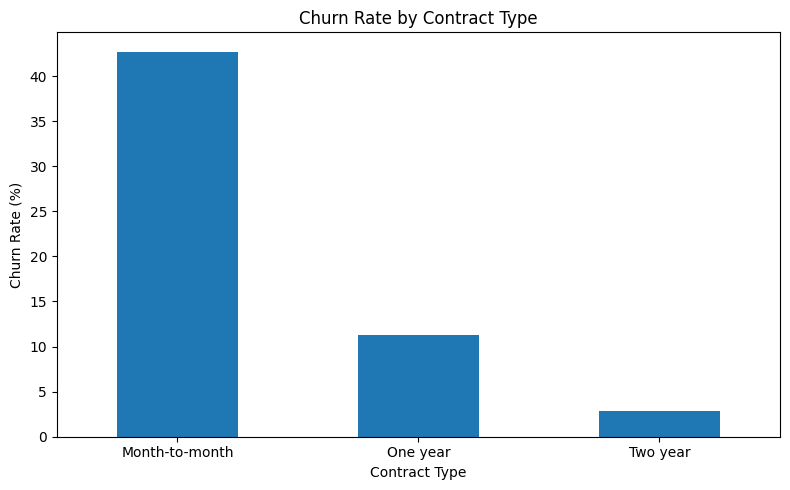

In [244]:
import matplotlib.pyplot as plt

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

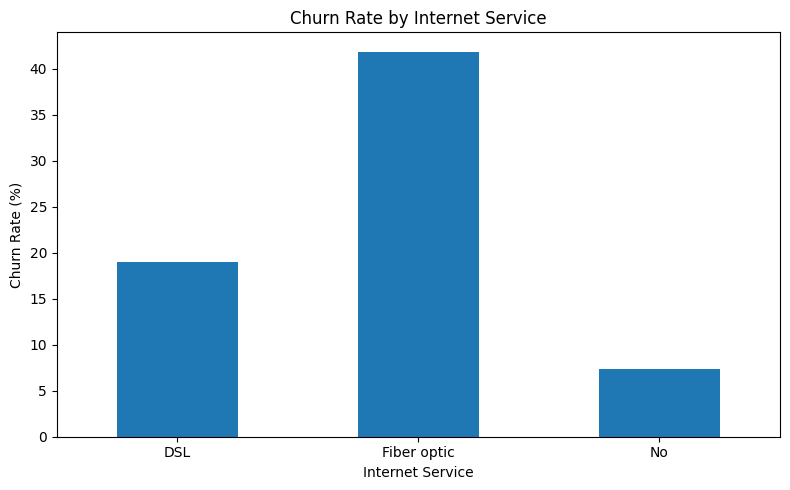

In [245]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn["Yes"].plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

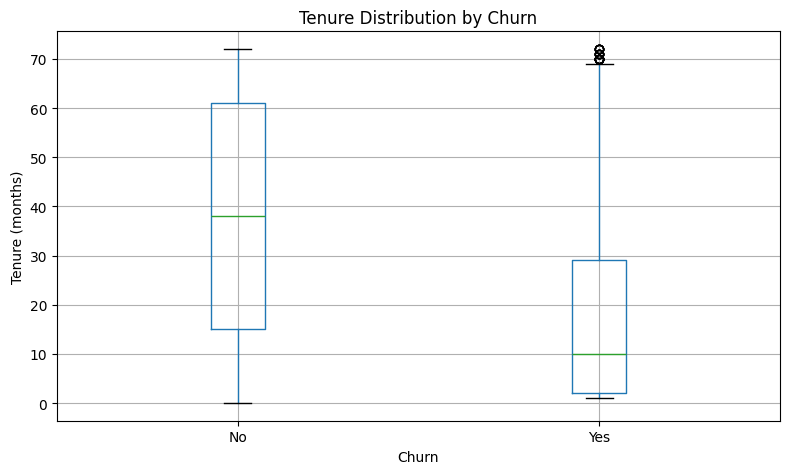

In [246]:
import matplotlib.pyplot as plt

df.boxplot(
    column="tenure",
    by="Churn",
    figsize=(8, 5)
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.tight_layout()
plt.show()

In [247]:
#Part 2: Predictive Modelling & Business Segmentation
# Task- 2 Data Cleaning & Preprocessing

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_numeric'],
      dtype='object')

In [248]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [249]:
df["TotalCharges"].str.strip().value_counts().head(15)

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
19.65,8
19.55,7
45.3,7
20.15,6


In [250]:
df[["TotalCharges", "tenure", "MonthlyCharges"]].dtypes

,0
TotalCharges,object
tenure,int64
MonthlyCharges,float64


In [251]:
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", "0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [252]:
df[["TotalCharges", "tenure", "MonthlyCharges"]].dtypes

,0
TotalCharges,float64
tenure,int64
MonthlyCharges,float64


In [253]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [254]:
X = df.drop(columns=["customerID", "Churn", "Churn_numeric"])
y = df["Churn"]

X.shape, y.shape

((7043, 19), (7043,))

In [255]:
#Task 3: Train, Evaluate, and Check Trust

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

In [256]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [257]:
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns
numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [258]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numerical", StandardScaler(), numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((5634, 45), (1409, 45))

In [259]:
#Churn Prediction Models
#baseline model - LogisticRegression


from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [260]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_baseline = baseline_model.predict(X_test_processed)
y_prob_baseline = baseline_model.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred_baseline, pos_label="Yes"))
print("F1-score:", f1_score(y_test, y_pred_baseline, pos_label="Yes"))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_baseline))

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1-score: 0.6040462427745664
ROC-AUC: 0.8421349040274871


#### Analytical Question A — Why Accuracy Alone Is Not Enough?

The baseline model achieved an accuracy of 80.55%, but accuracy alone is not sufficient for this churn problem because churn is the minority class. The model's recall was 55.88%, meaning it correctly identified only 55.88% of the customers who actually churned and missed approximately 44.12% of them. Since acquiring a new customer is more expensive than retaining an existing customer, missing customers who are likely to churn can result in lost revenue. Therefore, recall should be considered along with accuracy when evaluating the churn model.

In [261]:
# Complex Model — Random Forest

In [262]:
from sklearn.ensemble import RandomForestClassifier

complex_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

complex_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [263]:
#Complex Model Evaluation
y_pred_complex = complex_model.predict(X_test_processed)
y_prob_complex = complex_model.predict_proba(X_test_processed)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_complex))
print("Test Precision:", precision_score(y_test, y_pred_complex, pos_label="Yes"))
print("Test Recall:", recall_score(y_test, y_pred_complex, pos_label="Yes"))
print("Test F1-score:", f1_score(y_test, y_pred_complex, pos_label="Yes"))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_complex))

y_train_pred_complex = complex_model.predict(X_train_processed)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_complex))

Test Accuracy: 0.7856635911994322
Test Precision: 0.625
Test Recall: 0.48128342245989303
Test F1-score: 0.5438066465256798
Test ROC-AUC: 0.8200780180319822
Train Accuracy: 0.9980475683351083


#### Analytical Question B — Train vs Test Accuracy

The Random Forest model achieved 99.80% training accuracy but only 78.57% test accuracy, giving a large accuracy gap of 21.23 percentage points. This indicates substantial overfitting: the complex model fits the training data extremely well but does not generalize as well to unseen customers. In addition, its test recall was only 48.13%, compared with 55.88% for the Logistic Regression baseline. Therefore, the simpler Logistic Regression model is more trustworthy for this dataset because it performs better on unseen data and identifies more actual churners.

In [264]:
# Task 4 — Feature Importance and Business Interpretation
#Feature Importance

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": baseline_model.coef_[0]
})

importance_df["Absolute_Importance"] = importance_df["Importance"].abs()

importance_df = importance_df.sort_values(
    "Absolute_Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance,Absolute_Importance
42,numerical__tenure,-1.257539,1.257539
34,categorical__Contract_Two year,-0.776594,0.776594
11,categorical__InternetService_DSL,-0.648646,0.648646
12,categorical__InternetService_Fiber optic,0.634195,0.634195
43,numerical__MonthlyCharges,-0.591863,0.591863
32,categorical__Contract_Month-to-month,0.582883,0.582883
44,numerical__TotalCharges,0.536253,0.536253
35,categorical__PaperlessBilling_No,-0.343227,0.343227
13,categorical__InternetService_No,-0.300104,0.300104
15,categorical__OnlineSecurity_No internet service,-0.300104,0.300104


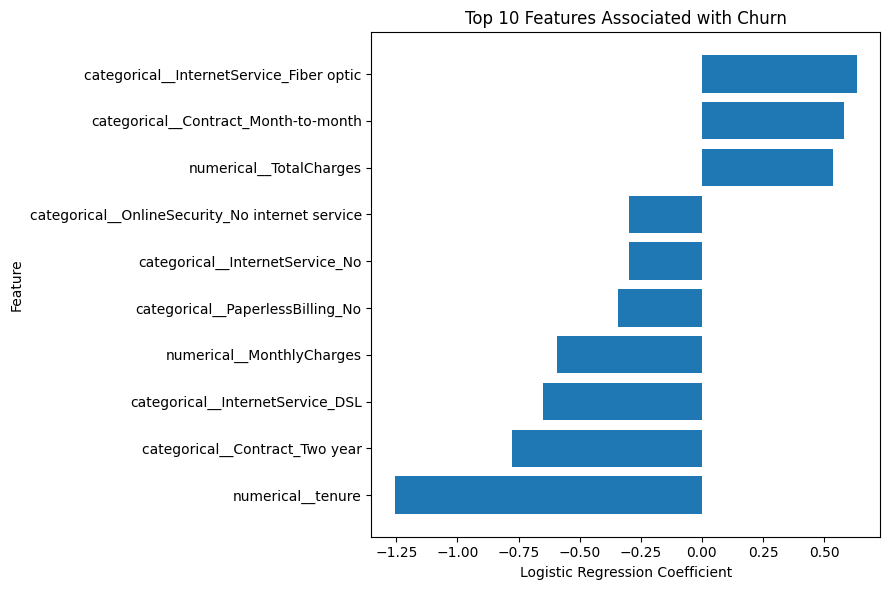

In [265]:
#Feature Importance Plot

top_features = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Associated with Churn")
plt.tight_layout()
plt.show()

# Analytical Question — Top 3 Features and Business Actions

The three strongest features by absolute Logistic Regression coefficient were tenure (-1.2575), two-year contract (-0.7766), and DSL internet service (-0.6486). The negative coefficients indicate that these categories are associated with lower churn probability in the model; they should not be interpreted as proof of causation.

1. Tenure (-1.2575): Focus retention efforts on newer customers and strengthen early-stage onboarding because longer-tenure customers show a lower predicted churn tendency.

2. Two-year contract (-0.7766): Encourage suitable month-to-month customers to consider longer-term contracts through targeted upgrade or loyalty offers, while avoiding the assumption that contract length itself causes lower churn.

3. DSL internet service (-0.6486): Review the experience and retention opportunities of DSL customers and use targeted service/support offers where appropriate, based on their individual risk rather than treating all DSL customers as high risk.

In [266]:
#Task 5: Segment Customers for Targeting
# Customer Risk Segments

from sklearn.cluster import KMeans

segment_df = df.loc[X_test.index, ["tenure", "MonthlyCharges"]].copy()

segment_df["ChurnProbability"] = y_prob_baseline

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

segment_df["Segment"] = kmeans.fit_predict(
    segment_df[["tenure", "MonthlyCharges", "ChurnProbability"]]
)

segment_summary = segment_df.groupby("Segment").agg(
    Customers=("Segment", "size"),
    AvgTenure=("tenure", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgChurnProbability=("ChurnProbability", "mean")
).round(2)

segment_summary

,Customers,AvgTenure,AvgMonthlyCharges,AvgChurnProbability
Segment,,,,
0,335,9.89,32.17,0.24
1,462,14.80,80.08,0.50
2,376,58.55,92.49,0.15
3,236,54.25,32.85,0.03


In [267]:
segment_names = {
    0: "New, Low-Spend, Moderate-Risk",
    1: "New, High-Spend, High-Risk",
    2: "Loyal, High-Spend, Moderate-Risk",
    3: "Loyal, Low-Spend, Low-Risk"
}

segment_summary["BusinessName"] = segment_summary.index.map(segment_names)

segment_summary

,Customers,AvgTenure,AvgMonthlyCharges,AvgChurnProbability,BusinessName
Segment,,,,,
0,335,9.89,32.17,0.24,"New, Low-Spend, Moderate-Risk"
1,462,14.80,80.08,0.50,"New, High-Spend, High-Risk"
2,376,58.55,92.49,0.15,"Loyal, High-Spend, Moderate-Risk"
3,236,54.25,32.85,0.03,"Loyal, Low-Spend, Low-Risk"


#Analytical Question — Recommended Segment for the CFO

Segment 1, the New, High-Spend, High-Risk segment, should be the first target for the retention campaign. It contains 462 customers with an average tenure of 14.80 months, average monthly charges of 80.08, and an average predicted churn probability of 50%. This combination represents high churn risk and meaningful recurring revenue at stake. The trade-off is that retention incentives may be spent on some customers who would not have churned, but the high risk and relatively high spend make this the strongest priority among the four segments.

In [268]:
#Part 3: GenAI Advisory Layer — Prompt Engineering & RAG
#Task 6: Build the Advisory Explanation

# Create a table of test customers and their predicted churn probabilities
high_risk_candidates = pd.DataFrame({
    "index": X_test.index,
    "risk_probability": y_prob_baseline,
    "tenure": X_test["tenure"].values
})

# Select high-risk customers with tenure >= 3 months
high_risk_candidates = high_risk_candidates[
    (high_risk_candidates["risk_probability"] >= 0.70) &
    (high_risk_candidates["tenure"] >= 3)
]

# Sort from highest to lowest churn risk
high_risk_candidates = high_risk_candidates.sort_values(
    "risk_probability",
    ascending=False
)

high_risk_candidates.head()

,index,risk_probability,tenure
1175,2631,0.828147,7
1164,6365,0.821692,7
647,2797,0.817586,3
627,3727,0.817042,3
1138,6894,0.815703,3


In [269]:
# Select the chosen high-risk customer
selected_index = 2631

customer_row = X_test.loc[[selected_index]]

# Transform the customer using the same preprocessing pipeline
customer_processed = preprocessor.transform(customer_row)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Convert transformed customer to a 1D array
if hasattr(customer_processed, "toarray"):
    customer_values = customer_processed.toarray()[0]
else:
    customer_values = customer_processed[0]

# Calculate contribution of each feature
contributions = customer_values * baseline_model.coef_[0]

contribution_df = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": contributions
})

# Remove protected demographic features from the explanation layer
protected_terms = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

allowed_contributions = contribution_df[
    ~contribution_df["Feature"].str.contains(
        "|".join(protected_terms),
        case=False,
        regex=True
    )
].copy()

# We want features contributing toward churn (positive contribution)
top_3_features = allowed_contributions[
    allowed_contributions["Contribution"] > 0
].sort_values(
    "Contribution",
    ascending=False
).head(3)

top_3_features

,Feature,Contribution
42,numerical__tenure,1.304558
12,categorical__InternetService_Fiber optic,0.634195
32,categorical__Contract_Month-to-month,0.582883


In [270]:
retention_playbook = {
    "Clause 1": "High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours.",

    "Clause 2": "Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused service or a contract upgrade offer.",

    "Clause 3": "New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team instead of the standard retention flow.",

    "Clause 4": "Non-Discrimination Rule: Retention explanations must never state or imply that gender, senior-citizen status, or family/partner status contributed to a customer's risk score, even where a statistical correlation exists in the data."
}

In [271]:
risk_probability = 0.828147
customer_tenure = 7

if customer_tenure < 3:
    retrieved_clause = retention_playbook["Clause 3"]
elif risk_probability >= 0.70:
    retrieved_clause = retention_playbook["Clause 1"]
elif risk_probability >= 0.40:
    retrieved_clause = retention_playbook["Clause 2"]
else:
    retrieved_clause = "No specific retention action required."

print("Retrieved clause:")
print(retrieved_clause)

Retrieved clause:
High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours.


In [272]:
# Customer information to send to the LLM
risk_probability = 0.828147
customer_tenure = 7

top_features = [
    "Low tenure",
    "Fiber optic internet service",
    "Month-to-month contract"
]

compliance_clause = retention_playbook["Clause 4"]

system_prompt = f"""
You are an AI retention advisor assisting a telecom retention agent.

Write a clear 3-4 sentence explanation for the retention agent.
Base your explanation ONLY on the supplied churn risk, tenure,
contributing features, and retrieved retention playbook clauses.

Do not state or imply that gender, SeniorCitizen status, Partner status,
Dependents status, family status, or any other protected demographic
attribute contributed to the customer's churn risk.

Do not invent any customer information or retention action.
"""

user_prompt = f"""
Customer churn probability: {risk_probability:.2%}
Customer tenure: {customer_tenure} months

Top contributing features:
1. {top_features[0]}
2. {top_features[1]}
3. {top_features[2]}

Retrieved retention clause:
{retrieved_clause}

Compliance rule:
{compliance_clause}

Explain the customer's churn risk and the recommended retention action.
"""

print(system_prompt)
print(user_prompt)


You are an AI retention advisor assisting a telecom retention agent.

Write a clear 3-4 sentence explanation for the retention agent.
Base your explanation ONLY on the supplied churn risk, tenure,
contributing features, and retrieved retention playbook clauses.

Do not state or imply that gender, SeniorCitizen status, Partner status,
Dependents status, family status, or any other protected demographic
attribute contributed to the customer's churn risk.

Do not invent any customer information or retention action.


Customer churn probability: 82.81%
Customer tenure: 7 months

Top contributing features:
1. Low tenure
2. Fiber optic internet service
3. Month-to-month contract

Retrieved retention clause:
High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours.

Compliance rule:
Non-Discrimination Rule: Retention explanations must never state or imply that gender, senior-citizen status, or family/partner status contributed to a c

In [273]:
!pip install -q google-genai

In [274]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")


In [275]:
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [276]:
from google import genai

client = genai.Client(api_key=GEMINI_API_KEY)

full_prompt = system_prompt + "\n\n" + user_prompt

try:
    response = client.models.generate_content(
        model="gemini-flash-lite-latest",
        contents=full_prompt
    )

    llm_output = response.text

    print("Exact LLM Output:")
    print(llm_output)

except Exception as e:
    print("ERROR:")
    print(e)

Exact LLM Output:
This customer presents a high churn risk of 82.81% driven primarily by their low tenure of 7 months, along with using fiber optic internet service and being on a month-to-month contract. To address this risk, the retention playbook dictates that you should offer the customer a loyalty discount. Additionally, you need to arrange for a retention specialist to call them back within 48 hours.


#Exact LLM Output:

This customer presents a high churn probability of 82.81% and a short tenure of just 7 months. Their risk is primarily driven by their brief time with the company, their use of fiber optic internet service, and their month-to-month contract. Per the retention playbook for high-risk accounts, you should offer a loyalty discount and arrange a callback from a retention specialist within 48 hours.

In [277]:
no_retrieval_prompt = f"""
You are an AI retention advisor assisting a telecom retention agent.

Customer churn probability: 82.81%
Customer tenure: 7 months

Top contributing features:
1. Low tenure
2. Fiber optic internet service
3. Month-to-month contract

Decide which retention risk clause should apply to this customer and
recommend the appropriate retention action.

Do not mention gender, SeniorCitizen status, Partner status,
Dependents status, or family status.

Answer in 3-4 sentences.
"""

response_no_retrieval = client.models.generate_content(
    model="gemini-flash-lite-latest",
    contents=no_retrieval_prompt
)

no_retrieval_output = response_no_retrieval.text

print("Exact No-Retrieval LLM Output:")
print(no_retrieval_output)

Exact No-Retrieval LLM Output:
This customer represents a critical retention risk due to their very low tenure of 7 months combined with a flexible month-to-month contract and a fiber optic service plan. This profile triggers the "Early-Stage Fiber Optic Churn Risk" clause, as new subscribers on non-binding agreements frequently disconnect before realizing the long-term value of premium high-speed services. To mitigate this high churn probability, the agent should immediately offer a promotion or bill credit for transitioning to an annual contract paired with a complimentary speed upgrade or bundled security feature.


# Task 6 - Analytical Question A — Effect of Skipping Retrieval

For the selected customer, the predicted churn probability was 82.81% and tenure was 7 months. With retrieval, the LLM correctly followed Clause 1 and recommended a loyalty discount and a callback from a retention specialist within 48 hours.

When retrieval was deliberately skipped, the LLM incorrectly selected a "New Customer Onboarding & Contract Transition" clause, even though the customer's tenure was 7 months and the actual new-customer Clause 3 applies only when tenure is below 3 months. It also invented actions that were not present in the supplied retention playbook, including migration to a discounted annual contract, a complimentary value-add, a high-speed data boost or security feature, and a proactive service check-in.

This is a grounding/hallucination failure: without retrieving the approved playbook, the LLM generated a plausible-sounding but unsupported clause and retention actions. This is more serious in a retention/compliance system than in a casual chatbot because an agent could act on an unauthorized offer or apply the wrong business policy to a real customer. Retrieval therefore provides an auditable link between the customer's risk information and the approved retention action.

# Task 6 - Analytical Question B: Demographic and Compliance Risk

Passing the full customer row to the LLM could expose demographic attributes such as gender, SeniorCitizen, Partner, and Dependents. Even if the prediction model used these variables internally, providing them to the LLM could cause the generated retention explanation to state or imply that a protected demographic or family characteristic contributed to the customer's churn risk. This would violate Clause 4 and create discrimination, compliance, and audit risks.

To prevent this, my code explicitly filtered gender, SeniorCitizen, Partner, and Dependents from the customer-level feature contributions before selecting the features supplied to the LLM. For the selected customer, the LLM received only the churn probability of 82.81%, tenure of 7 months, and the permitted contributing features: low tenure, Fiber optic internet service, and Month-to-month contract. The retrieved retention clause and the non-discrimination rule were also supplied in the grounded prompt. The full customer row and demographic values were never passed to the LLM.

In [278]:
#Part 4: Governance, Monitoring, Cost & the Board Memo
#Task 7: Executive Memo

#Task 7: Executive Memo

To: CFO and Retention Team
Subject: Customer Churn and Retention Recommendation

The overall churn rate in the dataset is 26.54%, with 1,869 out of 7,043 customers leaving. The main concern is customers on month-to-month contracts, where the churn rate is 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

For the first retention campaign, I recommend focusing on Segment 1- New, High-Spend, High-Risk customers. This group has 462 customers, an average tenure of 14.8 months, average monthly charges of 80.08, and an average churn probability of 50%. I selected this group because it has both a relatively high risk of leaving and higher monthly spending. The trade-off is that some customers who receive an offer may have stayed even without one, so the campaign could spend money unnecessarily. Even with this risk, I believe this segment is the best place to start because more revenue is at risk.

After the system is launched, I would compare the predicted churn risk with the actual churn rate following important business changes. For example, if the company increases fiber-optic prices or a competitor introduces a cheaper offer, actual churn may increase even though the model continues to predict lower risk. A consistent gap between predicted and actual churn after such a change would be a clear signal that customer behaviour has changed and the model should be retrained.

For governance, each LLM request should be logged with the information sent to the LLM, the retrieved playbook clause, the Clause 4 instruction, and the final response. These logs would allow an auditor to confirm that gender, SeniorCitizen, Partner and Dependents were excluded from every explanation request, rather than relying on a single test case.

Finally, generating a new LLM explanation for every at-risk customer every week could become expensive. To reduce API cost, I would reuse a previously generated explanation when the customer's risk tier, main contributing features and retrieved playbook clause have not changed. A new LLM call would only be made when these inputs change. The stored explanation would also keep its link to the retrieved playbook clause, so the grounding requirement is still maintained.

In [279]:
!pip install streamlit

In [280]:
import streamlit as st
print(st.__version__)

1.63.0


In [281]:
import joblib

joblib.dump(baseline_model, "churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model and preprocessor saved!")

Model and preprocessor saved!


In [282]:
import joblib

In [283]:
baseline_model = joblib.load("churn_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

In [284]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
from google import genai


# ============================================================
# LOAD MODEL
# ============================================================

baseline_model = joblib.load("churn_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Customer Churn AI Retention Advisor",
    page_icon="📡",
    layout="wide"
)


# ============================================================
# CSS
# ============================================================

st.markdown("""
<style>

/* Main page background */
[data-testid="stAppViewContainer"] {
    background: linear-gradient(
        135deg,
        #f5f8ff 0%,
        #edf3ff 55%,
        #fafcff 100%
    );
}

/* Main content area */
.block-container {
    max-width: 1400px;
    padding-top: 1.4rem;
    padding-bottom: 3rem;
}

/* Force readable text */
[data-testid="stAppViewContainer"] p {
    color: #26364f !important;
}

[data-testid="stAppViewContainer"] label {
    color: #26364f !important;
}

[data-testid="stAppViewContainer"] h1,
[data-testid="stAppViewContainer"] h2,
[data-testid="stAppViewContainer"] h3 {
    color: #173b7a !important;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: #f5f8ff;
    border-right: 1px solid #dce5f6;
}

[data-testid="stSidebar"] p,
[data-testid="stSidebar"] label {
    color: #203451 !important;
}

[data-testid="stSidebar"] h1,
[data-testid="stSidebar"] h2,
[data-testid="stSidebar"] h3 {
    color: #173b7a !important;
}


/* Hero banner */
.hero {
    background: linear-gradient(
        120deg,
        #2758df,
        #493ed9,
        #7629e6
    );

    padding: 30px 32px;
    border-radius: 22px;
    margin-bottom: 30px;

    box-shadow:
        0px 12px 32px rgba(48, 68, 160, 0.18);
}

.hero-title {
    color: white !important;
    font-size: 36px;
    font-weight: 800;
    margin-bottom: 10px;
}

.hero-subtitle {
    color: #eef2ff !important;
    font-size: 17px;
}


/* Metrics */
[data-testid="stMetric"] {
    background: white;
    border: 1px solid #e0e7f5;
    border-radius: 18px;
    padding: 20px;

    box-shadow:
        0px 5px 20px rgba(31, 50, 95, 0.07);
}

[data-testid="stMetricLabel"] p {
    color: #52627c !important;
}

[data-testid="stMetricValue"] {
    color: #173b7a !important;
}


/* Containers */
[data-testid="stVerticalBlockBorderWrapper"] {
    background: rgba(255,255,255,0.94);
    border-radius: 18px;
    border-color: #e1e7f4 !important;

    box-shadow:
        0px 5px 18px rgba(32, 52, 95, 0.06);
}


/* Button */
.stButton > button {
    width: 100%;

    background: linear-gradient(
        90deg,
        #2866ef,
        #5844e8,
        #8236eb
    );

    color: white !important;

    border: none;
    border-radius: 12px;

    padding: 0.75rem 1rem;

    font-weight: 700;
}

.stButton > button:hover {
    color: white !important;
    border: none !important;
}


/* Progress bar */
[data-testid="stProgress"] > div > div > div {
    background: linear-gradient(
        90deg,
        #2563eb,
        #7c3aed
    );
}


/* Divider */
hr {
    border-color: #dce4f3;
}


/* Hide Streamlit footer */
footer {
    visibility: hidden;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# HEADER
# ============================================================

st.markdown(
    "<div class='hero'>"
    "<div class='hero-title'>📡 Customer Churn Risk & AI Retention Advisor</div>"
    "<div class='hero-subtitle'>Machine-learning churn prediction with grounded AI-powered retention guidance.</div>"
    "</div>",
    unsafe_allow_html=True
)


# ============================================================
# RETENTION PLAYBOOK
# ============================================================

retention_playbook = {

    "Clause 1":
    "High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours.",

    "Clause 2":
    "Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused service or a contract upgrade offer.",

    "Clause 3":
    "New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team instead of the standard retention flow.",

    "Clause 4":
    "Non-Discrimination Rule: Retention explanations must never state or imply that gender, senior-citizen status, or family/partner status contributed to a customer's risk score, even where a statistical correlation exists in the data."
}


# ============================================================
# SIDEBAR INPUTS
# ============================================================

with st.sidebar:

    st.header("👤 Customer Details")

    st.caption(
        "Enter customer service and billing information."
    )

    st.subheader("Demographics")

    gender = st.selectbox(
        "Gender",
        ["Female", "Male"]
    )

    senior_citizen = st.selectbox(
        "Senior Citizen",
        [0, 1]
    )

    partner = st.selectbox(
        "Partner",
        ["Yes", "No"]
    )

    dependents = st.selectbox(
        "Dependents",
        ["Yes", "No"]
    )


    st.divider()

    st.subheader("Account")

    tenure = st.number_input(
        "Tenure (months)",
        min_value=0,
        max_value=100,
        value=7,
        step=1
    )

    contract = st.selectbox(
        "Contract",
        [
            "Month-to-month",
            "One year",
            "Two year"
        ]
    )

    paperless_billing = st.selectbox(
        "Paperless Billing",
        ["Yes", "No"]
    )

    payment_method = st.selectbox(
        "Payment Method",
        [
            "Electronic check",
            "Mailed check",
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]
    )

    monthly_charges = st.number_input(
        "Monthly Charges",
        min_value=0.0,
        max_value=1000.0,
        value=80.0,
        step=1.0,
        format="%.2f"
    )

    total_charges = st.number_input(
        "Total Charges",
        min_value=0.0,
        max_value=100000.0,
        value=560.0,
        step=10.0,
        format="%.2f"
    )


    st.divider()

    st.subheader("Services")

    phone_service = st.selectbox(
        "Phone Service",
        ["Yes", "No"]
    )

    multiple_lines = st.selectbox(
        "Multiple Lines",
        [
            "No",
            "Yes",
            "No phone service"
        ]
    )

    internet_service = st.selectbox(
        "Internet Service",
        [
            "DSL",
            "Fiber optic",
            "No"
        ]
    )

    online_security = st.selectbox(
        "Online Security",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )

    online_backup = st.selectbox(
        "Online Backup",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )

    device_protection = st.selectbox(
        "Device Protection",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )

    tech_support = st.selectbox(
        "Tech Support",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )

    streaming_tv = st.selectbox(
        "Streaming TV",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )

    streaming_movies = st.selectbox(
        "Streaming Movies",
        [
            "Yes",
            "No",
            "No internet service"
        ]
    )


    st.divider()

    analyse_button = st.button(
        "🔍 Analyse Customer",
        use_container_width=True
    )


# ============================================================
# DEFAULT SCREEN
# ============================================================

if not analyse_button:

    st.header("How the Advisor Works")

    col1, col2, col3 = st.columns(3)


    with col1:

        with st.container(border=True):

            st.subheader("📊 1. Predict")

            st.write(
                "The Logistic Regression model estimates "
                "the customer's probability of churn."
            )


    with col2:

        with st.container(border=True):

            st.subheader("🎯 2. Retrieve")

            st.write(
                "The system retrieves the appropriate "
                "retention playbook clause."
            )


    with col3:

        with st.container(border=True):

            st.subheader("🤖 3. Explain")

            st.write(
                "Gemini generates a grounded explanation "
                "using permitted risk drivers."
            )


    st.info(
        "👈 Enter customer details in the sidebar "
        "and click Analyse Customer."
    )


# ============================================================
# ANALYSE CUSTOMER
# ============================================================

if analyse_button:


    # ========================================================
    # CUSTOMER DATA
    # ========================================================

    customer = pd.DataFrame([{

        "gender": gender,

        "SeniorCitizen":
        senior_citizen,

        "Partner":
        partner,

        "Dependents":
        dependents,

        "tenure":
        tenure,

        "PhoneService":
        phone_service,

        "MultipleLines":
        multiple_lines,

        "InternetService":
        internet_service,

        "OnlineSecurity":
        online_security,

        "OnlineBackup":
        online_backup,

        "DeviceProtection":
        device_protection,

        "TechSupport":
        tech_support,

        "StreamingTV":
        streaming_tv,

        "StreamingMovies":
        streaming_movies,

        "Contract":
        contract,

        "PaperlessBilling":
        paperless_billing,

        "PaymentMethod":
        payment_method,

        "MonthlyCharges":
        monthly_charges,

        "TotalCharges":
        total_charges

    }])


    # ========================================================
    # MODEL PREDICTION
    # ========================================================

    customer_processed = (
        preprocessor.transform(
            customer
        )
    )


    classes = list(
        baseline_model.classes_
    )


    if "Yes" in classes:

        yes_index = (
            classes.index("Yes")
        )

    elif 1 in classes:

        yes_index = (
            classes.index(1)
        )

    else:

        yes_index = 1


    risk_probability = (
        baseline_model
        .predict_proba(
            customer_processed
        )[0, yes_index]
    )


    # ========================================================
    # RETRIEVAL
    # RUNS ON EVERY REQUEST
    # ========================================================

    if tenure < 3:

        risk_tier = (
            "New Customer"
        )

        clause_name = (
            "Clause 3"
        )

        retrieved_clause = (
            retention_playbook[
                "Clause 3"
            ]
        )


    elif risk_probability >= 0.70:

        risk_tier = (
            "High Risk"
        )

        clause_name = (
            "Clause 1"
        )

        retrieved_clause = (
            retention_playbook[
                "Clause 1"
            ]
        )


    elif risk_probability >= 0.40:

        risk_tier = (
            "Moderate Risk"
        )

        clause_name = (
            "Clause 2"
        )

        retrieved_clause = (
            retention_playbook[
                "Clause 2"
            ]
        )


    else:

        risk_tier = (
            "Low Risk"
        )

        clause_name = (
            "No matching retention clause"
        )

        retrieved_clause = (
            "No specific retention action "
            "is required under the "
            "supplied playbook."
        )


    # ========================================================
    # FEATURE CONTRIBUTIONS
    # ========================================================

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )


    if hasattr(
        customer_processed,
        "toarray"
    ):

        customer_values = (
            customer_processed
            .toarray()[0]
        )

    else:

        customer_values = (
            np.asarray(
                customer_processed
            ).ravel()
        )


    contributions = (
        customer_values
        *
        baseline_model.coef_[0]
    )


    contribution_df = (
        pd.DataFrame({

            "Feature":
            feature_names,

            "Contribution":
            contributions

        })
    )


    # ========================================================
    # EXCLUDE PROTECTED DEMOGRAPHICS
    # ========================================================

    protected_terms = [

        "gender",

        "SeniorCitizen",

        "Partner",

        "Dependents"

    ]


    protected_pattern = (
        "|".join(
            protected_terms
        )
    )


    allowed_contributions = (
        contribution_df[

            ~contribution_df[
                "Feature"
            ].str.contains(

                protected_pattern,

                case=False,

                regex=True

            )

        ].copy()
    )


    # ========================================================
    # TOP 3 RISK CONTRIBUTORS
    # ========================================================

    top_3 = (

        allowed_contributions[

            allowed_contributions[
                "Contribution"
            ] > 0

        ]

        .sort_values(

            "Contribution",

            ascending=False

        )

        .head(3)

    )


    # ========================================================
    # CLEAN FEATURE NAMES
    # ========================================================

    cleaned_features = []


    for feature in (
        top_3["Feature"]
        .tolist()
    ):

        cleaned = (
            feature.replace(
                "categorical__",
                ""
            )
        )

        cleaned = (
            cleaned.replace(
                "numerical__",
                ""
            )
        )

        cleaned = (
            cleaned.replace(
                "_",
                " "
            )
        )

        cleaned_features.append(
            cleaned
        )


    # ========================================================
    # CUSTOMER RISK ASSESSMENT
    # ========================================================

    st.header(
        "📊 Customer Risk Assessment"
    )


    metric1, metric2, metric3 = (
        st.columns(3)
    )


    with metric1:

        st.metric(
            "Churn Probability",
            f"{risk_probability:.2%}"
        )


    with metric2:

        st.metric(
            "Customer Tenure",
            f"{tenure} months"
        )


    with metric3:

        st.metric(
            "Monthly Charges",
            f"{monthly_charges:.2f}"
        )


    st.write("")

    st.subheader(
        "🚦 Risk Classification"
    )


    if risk_tier == "High Risk":

        st.error(
            f"🔴 HIGH RISK — "
            f"{risk_probability:.2%} "
            f"predicted churn probability"
        )


    elif risk_tier == "Moderate Risk":

        st.warning(
            f"🟠 MODERATE RISK — "
            f"{risk_probability:.2%} "
            f"predicted churn probability"
        )


    elif risk_tier == "New Customer":

        st.info(
            f"🔵 NEW CUSTOMER — "
            f"{risk_probability:.2%} "
            f"predicted churn probability. "
            f"Onboarding flow takes priority."
        )


    else:

        st.success(
            f"🟢 LOW RISK — "
            f"{risk_probability:.2%} "
            f"predicted churn probability"
        )


    # ========================================================
    # RISK PROGRESS BAR
    # ========================================================

    st.subheader(
        "Predicted Churn Risk"
    )


    progress_value = int(
        round(
            risk_probability * 100
        )
    )


    progress_value = max(
        0,
        min(
            100,
            progress_value
        )
    )


    st.progress(
        progress_value
    )


    st.caption(
        f"Model probability: "
        f"{risk_probability:.2%}"
    )


    # ========================================================
    # RETENTION PLAYBOOK + DRIVERS
    # ========================================================

    left_col, right_col = (
        st.columns(2)
    )


    with left_col:

        with st.container(
            border=True
        ):

            st.subheader(
                "🎯 Retention Playbook"
            )

            st.write(
                f"**{clause_name}**"
            )

            st.info(
                retrieved_clause
            )


    with right_col:

        with st.container(
            border=True
        ):

            st.subheader(
                "📌 Key Churn-Risk Drivers"
            )


            if len(
                cleaned_features
            ) > 0:

                for i, feature in enumerate(
                    cleaned_features,
                    start=1
                ):

                    st.write(
                        f"**{i}. {feature}**"
                    )


            else:

                st.write(
                    "No positive "
                    "non-demographic "
                    "risk contributors "
                    "were identified."
                )


    # ========================================================
    # BUILD LLM FEATURE TEXT
    # ========================================================

    if len(
        cleaned_features
    ) > 0:

        feature_text = (
            "\n".join(
                [
                    f"{i + 1}. {feature}"

                    for i, feature
                    in enumerate(
                        cleaned_features
                    )
                ]
            )
        )


    else:

        feature_text = (
            "No positive permitted "
            "contributing features "
            "available."
        )


    compliance_clause = (
        retention_playbook[
            "Clause 4"
        ]
    )


    # ========================================================
    # SYSTEM PROMPT
    # ========================================================

    system_prompt = """

You are an AI retention advisor assisting a telecom retention agent.

Write a clear 3-4 sentence explanation for the retention agent.

Base your explanation ONLY on:
- the supplied churn probability,
- assigned risk tier,
- tenure,
- permitted contributing features,
- and the retrieved retention playbook clause.

Use the supplied risk tier exactly as given.

Do not independently create or change the customer's risk tier.

Do not state or imply that gender, SeniorCitizen status,
Partner status, Dependents status, family status,
or any other protected demographic attribute contributed
to the customer's churn risk.

Do not invent customer information.

Do not invent a retention action.

Only recommend an action that appears in the retrieved
retention playbook clause.

"""


    # ========================================================
    # USER PROMPT
    # ========================================================

    user_prompt = f"""

Customer churn probability:
{risk_probability:.2%}

Assigned risk tier:
{risk_tier}

Customer tenure:
{tenure} months

Permitted top contributing features:
{feature_text}

Retrieved retention clause:
{retrieved_clause}

Compliance rule:
{compliance_clause}

Write the retention-agent explanation.

Use the assigned risk tier exactly as provided.

Do not create a different risk classification.

Do not recommend any action that is not contained
in the retrieved retention clause.

"""


    # ========================================================
    # AI RETENTION ADVISOR
    # ========================================================

    st.header(
        "🤖 AI Retention Advisor"
    )


    try:

        api_key = (
            os.getenv(
                "GEMINI_API_KEY"
            )
        )


        if not api_key:

            st.warning(
                "Gemini API key "
                "is not available. "
                "Prediction and retrieval "
                "still completed successfully."
            )


        else:

            client = (
                genai.Client(
                    api_key=api_key
                )
            )


            full_prompt = (
                system_prompt
                +
                "\n\n"
                +
                user_prompt
            )


            with st.spinner(
                "Generating grounded "
                "retention explanation..."
            ):

                response = (
                    client.models
                    .generate_content(

                        model=
                        "gemini-flash-lite-latest",

                        contents=
                        full_prompt

                    )
                )


            with st.container(
                border=True
            ):

                st.subheader(
                    "💡 AI Recommendation"
                )

                st.write(
                    response.text
                )


    except Exception as e:

        st.warning(
            "The churn prediction "
            "and retrieval worked, "
            "but the AI explanation "
            "could not be generated."
        )

        st.error(
            str(e)
        )


    # ========================================================
    # RESPONSIBLE AI
    # ========================================================

    st.header(
        "🛡️ Responsible AI Safeguard"
    )


    st.info(
        "Gender, SeniorCitizen, Partner and Dependents "
        "are excluded from the LLM explanation layer. "
        "The recommendation is grounded in the retrieved "
        "retention playbook clause."
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Customer Churn Risk & AI Retention Advisor • "
    "Machine Learning + Grounded GenAI Decision Support"
)

Overwriting app.py


In [285]:
!pkill -f streamlit

In [286]:
!streamlit run app.py \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  --server.address 0.0.0.0 \
  &>/content/streamlit.log &

In [287]:
from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print(url)

https://8501-m-s-kkb-use1c2-2fya4zthw2jtv-c.us-east1-2.prod.colab.dev
